In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'gtsrb-german-traffic-sign' dataset.
Path to dataset files: /kaggle/input/gtsrb-german-traffic-sign


In [ ]:
import os

print(os.listdir(path))

['Meta', 'meta', 'Meta.csv', 'Train.csv', 'Test.csv', 'Test', 'test', 'Train', 'train']


In [ ]:
import os

dataset_path = path  # path bạn đã có từ kagglehub
train_folder = os.path.join(dataset_path, "Train")
test_folder  = os.path.join(dataset_path, "Test")

train_csv = os.path.join(dataset_path, "Train.csv")
test_csv  = os.path.join(dataset_path, "Test.csv")

print(train_folder, test_folder)
print(train_csv, test_csv)


/kaggle/input/gtsrb-german-traffic-sign/Train /kaggle/input/gtsrb-german-traffic-sign/Test
/kaggle/input/gtsrb-german-traffic-sign/Train.csv /kaggle/input/gtsrb-german-traffic-sign/Test.csv


In [ ]:
import pandas as pd

df_train = pd.read_csv(train_csv)
df_test  = pd.read_csv(test_csv)

df_train.head(), df_train.shape



(   Width  Height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  ClassId  \
 0     27      26       5       5      22      20       20   
 1     28      27       5       6      23      22       20   
 2     29      26       6       5      24      21       20   
 3     28      27       5       6      23      22       20   
 4     28      26       5       5      23      21       20   
 
                              Path  
 0  Train/20/00020_00000_00000.png  
 1  Train/20/00020_00000_00001.png  
 2  Train/20/00020_00000_00002.png  
 3  Train/20/00020_00000_00003.png  
 4  Train/20/00020_00000_00004.png  ,
 (39209, 8))

<Axes: title={'center': 'Number of samples per class'}, xlabel='ClassId'>

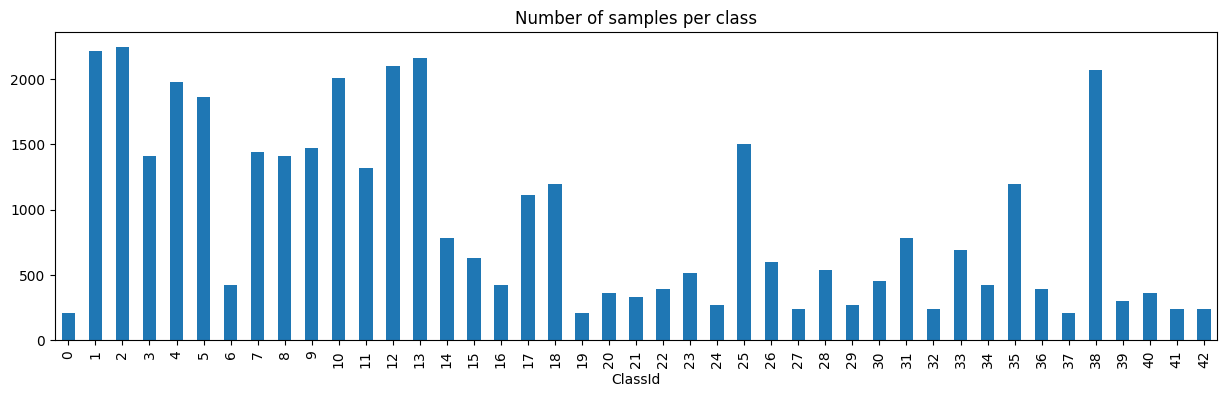

In [ ]:
df_train['ClassId'].value_counts().sort_index().plot(
    kind='bar',
    figsize=(15,4),
    title="Number of samples per class"
)


In [ ]:
import cv2
import numpy as np
import glob

image_paths = glob.glob(train_folder + "/**/*.png", recursive=True)

sizes = []

for p in image_paths[:30]:  # đọc 3000 ảnh đầu để tăng tốc
    img = cv2.imread(p)
    if img is not None:
        h, w = img.shape[:2]
        sizes.append((w, h))

sizes = np.array(sizes)
print("Avg:", sizes.mean(axis=0))
print("Min:", sizes.min(axis=0))
print("Max:", sizes.max(axis=0))


Avg: [42.16666667 42.8       ]
Min: [26 25]
Max: [74 76]


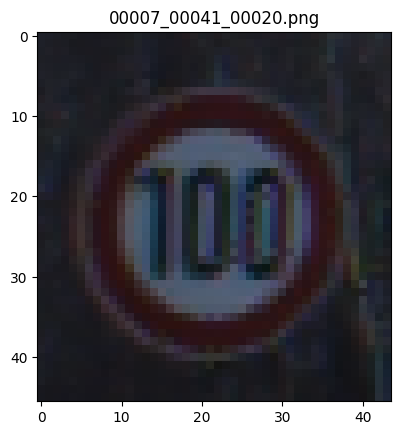

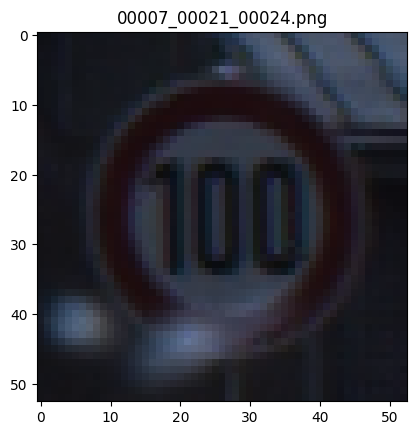

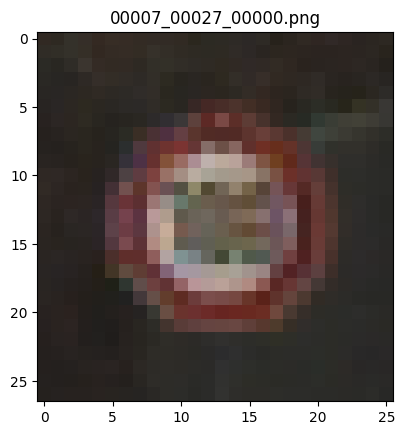

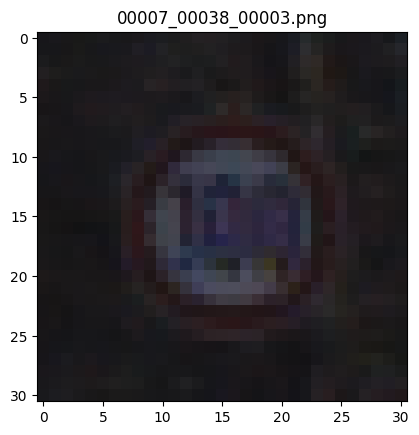

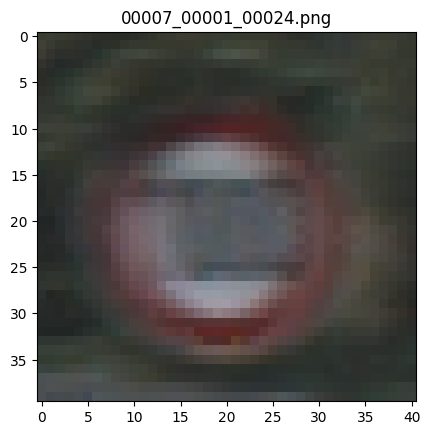

In [ ]:
import matplotlib.pyplot as plt
import cv2

sample_imgs = image_paths[:5]

for p in sample_imgs:
    img = cv2.imread(p)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.title(os.path.basename(p))
    plt.show()


In [ ]:
df_train[['ClassId','Roi.X1','Roi.Y1','Roi.X2','Roi.Y2']].head()


,ClassId,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2
0,20,5,5,22,20
1,20,5,6,23,22
2,20,6,5,24,21
3,20,5,6,23,22
4,20,5,5,23,21


In [ ]:
import os

root = "/kaggle/input/gtsrb-german-traffic-sign"

for r, d, f in os.walk(root):
    print("DIR:", r)
    print("SUBDIRS:", d[:10])
    print("FILES:", f[:10])
    print("-----------")
    break


DIR: /kaggle/input/gtsrb-german-traffic-sign
SUBDIRS: ['Meta', 'meta', 'Test', 'test', 'Train', 'train']
FILES: ['Meta.csv', 'Train.csv', 'Test.csv']
-----------


In [ ]:
root = "/kaggle/input/gtsrb-german-traffic-sign/Train"

for r, d, f in os.walk(root):
    print(r, d[:5], f[:5])
    break


/kaggle/input/gtsrb-german-traffic-sign/Train ['7', '17', '19', '22', '2'] []


In [ ]:
import os
import cv2
import pandas as pd
from tqdm import tqdm

# ==========================
# 1. CẤU HÌNH ĐƯỜNG DẪN
# ==========================

DATASET_DIR = path   # thư mục chứa Train/ + Train.csv
OUTPUT_DIR = "/content/resized_images"
os.makedirs(OUTPUT_DIR, exist_ok=True)

CSV_OUT = "/content/train_resized.csv"

# ==========================
# 2. ĐỌC CSV GỐC
# ==========================

df = pd.read_csv(os.path.join(DATASET_DIR, "Train.csv"))

# ==========================
# 3. THÔNG SỐ RESIZE
# ==========================

NEW_W, NEW_H = 128, 128

rows_new = []

# ==========================
# 4. XỬ LÝ TỪNG ẢNH
# ==========================

for idx, row in tqdm(df.iterrows(), total=len(df)):

    img_path = os.path.join(DATASET_DIR, row["Path"])
    print(f"\n[{idx+1}/{len(df)}] Processing: {row['Path']}")

    img = cv2.imread(img_path)
    if img is None:
        print(f"⚠️ Cannot read image: {img_path}")
        continue

    # ------------------------------
    # Lấy kích thước gốc từ CSV
    # ------------------------------
    orig_w = row["Width"]
    orig_h = row["Height"]

    sx = NEW_W / orig_w
    sy = NEW_H / orig_h

    # ------------------------------
    # Resize ảnh
    # ------------------------------
    img_resized = cv2.resize(img, (NEW_W, NEW_H))

    # ------------------------------
    # Scale lại BBOX
    # ------------------------------
    xmin = int(row["Roi.X1"] * sx)
    ymin = int(row["Roi.Y1"] * sy)
    xmax = int(row["Roi.X2"] * sx)
    ymax = int(row["Roi.Y2"] * sy)

    # ------------------------------
    # Lưu ảnh ra thư mục mới
    # ------------------------------
    out_path = os.path.join(OUTPUT_DIR, row["Path"])
    os.makedirs(os.path.dirname(out_path), exist_ok=True)

    cv2.imwrite(out_path, img_resized)

    print(f"✔ Saved: {out_path}")
    print(f"→ New BBox: {xmin},{ymin},{xmax},{ymax}")

    # ------------------------------
    # Ghi vào CSV mới
    # ------------------------------
    rows_new.append({
        "Width": NEW_W,
        "Height": NEW_H,
        "Roi.X1": xmin,
        "Roi.Y1": ymin,
        "Roi.X2": xmax,
        "Roi.Y2": ymax,
        "ClassId": row["ClassId"],
        "Path": row["Path"]
    })

# ==========================
# 5. GHI CSV MỚI
# ==========================

df_new = pd.DataFrame(rows_new)
df_new.to_csv(CSV_OUT, index=False)

print("\n🎉 DONE — resized images + updated bbox saved!")
print(f"📁 Images saved at: {OUTPUT_DIR}")
print(f"📄 CSV saved at: {CSV_OUT}")


In [ ]:
import shutil
import os

ENHANCE_DIR = "/content/enhanced_images"

# Xóa thư mục nếu tồn tại
if os.path.exists(ENHANCE_DIR):
    shutil.rmtree(ENHANCE_DIR)
    print("Đã xóa thư mục enhance_images cũ.")

# Tạo lại thư mục rỗng
os.makedirs(ENHANCE_DIR, exist_ok=True)
print("Đã tạo thư mục enhance_images mới.")


Đã xóa thư mục enhance_images cũ.
Đã tạo thư mục enhance_images mới.


In [ ]:
import cv2
import numpy as np

def blur_detector(image_path, lap_th=5, svd_th=0.65, fft_th=0.12):
    """
    Trả về True nếu ảnh mờ, False nếu ảnh rõ.
    Kết hợp Laplacian + SVD + FFT.
    """

    img = cv2.imread(image_path)
    if img is None:
        return True  # xem như ảnh lỗi = mờ

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # ===============================
    # 1) Laplacian Variance (đo cạnh)
    # ===============================
    lap_var = cv2.Laplacian(gray, cv2.CV_64F).var()

    # ===============================
    # 2) SVD Sharpness (đo cấu trúc)
    # ===============================
    U, S, Vt = np.linalg.svd(gray.astype(np.float32))
    svd_score = S[0] / (S.sum() + 1e-8)

    # ===============================
    # 3) FFT High-Frequency Energy
    # ===============================
    f = np.fft.fft2(gray)
    fshift = np.fft.fftshift(f)
    magnitude = np.abs(fshift)
    high_freq = magnitude[int(0.25*gray.shape[0]):int(0.75*gray.shape[0]),
                          int(0.25*gray.shape[1]):int(0.75*gray.shape[1])]
    fft_score = np.mean(high_freq) / (np.mean(magnitude) + 1e-8)

    # ===============================
    # NGƯỠNG QUYẾT ĐỊNH
    # Chỉ khi cả 3 score đều thấp → ảnh mới mờ thực sự
    # ===============================
    blurry = (
        lap_var < lap_th and
        svd_score < svd_th and
        fft_score < fft_th
    )

    return blurry


In [ ]:
import os
import shutil
from tqdm import tqdm

INPUT_DIR = "/content/resized_images/Train"
GOOD_DIR  = "/content/clean_images"
BAD_DIR   = "/content/bad_images"

os.makedirs(GOOD_DIR, exist_ok=True)
os.makedirs(BAD_DIR,  exist_ok=True)

bad_count = 0

for class_id in sorted(os.listdir(INPUT_DIR)):
    class_path = os.path.join(INPUT_DIR, class_id)
    if not os.path.isdir(class_path):
        continue

    out_good = os.path.join(GOOD_DIR, class_id)
    out_bad  = os.path.join(BAD_DIR, class_id)
    os.makedirs(out_good, exist_ok=True)
    os.makedirs(out_bad, exist_ok=True)

    print(f"Processing class {class_id}...")

    for file in tqdm(os.listdir(class_path)):
        if not file.lower().endswith((".jpg", ".jpeg", ".png", ".ppm", ".bmp")):
            continue

        src = os.path.join(class_path, file)

        if blur_detector(src):
            bad_count += 1
            shutil.copy2(src, os.path.join(out_bad, file))
        else:
            shutil.copy2(src, os.path.join(out_good, file))

print("DONE — blurry images:", bad_count)


Processing class 0...


100%|██████████| 210/210 [00:01<00:00, 118.19it/s]


Processing class 1...


100%|██████████| 2220/2220 [00:19<00:00, 115.71it/s]


Processing class 10...


...

Processing class 8...


100%|██████████| 1410/1410 [00:13<00:00, 107.47it/s]


Processing class 9...


100%|██████████| 1470/1470 [00:13<00:00, 106.20it/s]

DONE — blurry images: 0


In [ ]:
import os
import cv2
from tqdm import tqdm
import numpy as np

# ==========================
# 1. ĐƯỜNG DẪN
# ==========================

# Ảnh resize tạo ra từ bước trước
RESIZED_DIR = "/content/clean_images"

# Thư mục xuất ảnh enhance
OUTPUT_DIR = "/content/enhanced_images/Train"
os.makedirs(OUTPUT_DIR, exist_ok=True)


# ==========================
# 2. HÀM ENHANCE
# ==========================

def enhance_image(img):
    # KHÔNG resize nữa vì ảnh đã uniform 128x128
    # img = cv2.resize(img, (128, 128))

    # 1. Denoise
    img_denoised = cv2.fastNlMeansDenoisingColored(img, None, 10, 10, 7, 21)

    # 2. CLAHE giữ màu
    lab = cv2.cvtColor(img_denoised, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8,8))
    l_clahe = clahe.apply(l)
    lab_clahe = cv2.merge((l_clahe, a, b))
    img_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2BGR)

    # 3. Sharpen
    kernel = np.array([[0, -1, 0],
                       [-1, 5, -1],
                       [0, -1, 0]])
    img_sharp = cv2.filter2D(img_clahe, -1, kernel)

    # 4. Gamma correction
    gamma = 1.15
    table = np.array([((i / 255.0) ** (1/gamma)) * 255 for i in range(256)]).astype("uint8")
    img_gamma = cv2.LUT(img_sharp, table)

    return img_gamma


# ==========================
# 3. ENHANCE TỪNG CLASS
# ==========================

for class_id in sorted(os.listdir(RESIZED_DIR)):
    class_path = os.path.join(RESIZED_DIR, class_id)
    if not os.path.isdir(class_path):
        continue

    out_dir = os.path.join(OUTPUT_DIR, class_id)
    os.makedirs(out_dir, exist_ok=True)

    print(f"Enhancing class {class_id}...")

    for file in tqdm(os.listdir(class_path)):
        if not file.lower().endswith((".jpg", ".jpeg", ".png", ".ppm", ".bmp")):
            continue

        img_path = os.path.join(class_path, file)
        img = cv2.imread(img_path)

        if img is None:
            print(f"⚠️ Cannot read: {img_path}")
            continue

        enhanced = enhance_image(img)

        cv2.imwrite(os.path.join(out_dir, file), enhanced)

print("DONE — Enhanced images saved at /content/enhanced_images/Train")


Enhancing class 0...


100%|██████████| 210/210 [00:14<00:00, 14.35it/s]


Enhancing class 1...


100%|██████████| 2220/2220 [02:38<00:00, 14.00it/s]


Enhancing class 10...


...

Enhancing class 8...


100%|██████████| 1410/1410 [01:40<00:00, 14.06it/s]


Enhancing class 9...


100%|██████████| 1470/1470 [01:46<00:00, 13.84it/s]

DONE — Enhanced images saved at /content/enhanced_images/Train


In [ ]:
import os

root = "/content/clean_images"

for r, d, f in os.walk(root):
    print("DIR:", r)
    print("SUBDIRS:", d[:10])
    print("FILES:", f[:10])
    print("-----------")
    break

DIR: /content/clean_images
SUBDIRS: ['35', '21', '24', '20', '36', '8', '39', '12', '4', '17']
FILES: []
-----------


In [ ]:
# Cập nhật lại file csv

import pandas as pd
import os

CLEAN_DIR = "/content/clean_images"
TRAIN_CSV = "/content/train_resized.csv"   # sửa đúng đường dẫn CSV của bạn
OUT_CSV = "/content/Train_clean.csv"

# Load CSV gốc
df = pd.read_csv(TRAIN_CSV)
print("Số dòng ban đầu:", len(df))

# Lấy danh sách class còn lại trong clean_images
existing_classes = set(os.listdir(CLEAN_DIR))
print("Class còn lại sau khi lọc ảnh:", existing_classes)

# Hàm kiểm tra xem ảnh có tồn tại trong clean_images hay không
def exists_in_clean(row):
    class_id = str(row["ClassId"])

    # nếu class không còn -> loại
    if class_id not in existing_classes:
        return False

    filename = os.path.basename(row["Path"])
    img_path = os.path.join(CLEAN_DIR, class_id, filename)

    return os.path.exists(img_path)

# Lọc CSV theo ảnh vẫn tồn tại
df_clean = df[df.apply(exists_in_clean, axis=1)]

# Xuất CSV mới
df_clean.to_csv(OUT_CSV, index=False)

print("Số dòng sau khi lọc:", len(df_clean))
print("CSV sạch lưu tại:", OUT_CSV)


Số dòng ban đầu: 39209
Class còn lại sau khi lọc ảnh: {'14', '27', '26', '38', '11', '36', '30', '34', '3', '20', '17', '16', '7', '0', '23', '10', '2', '13', '6', '33', '21', '25', '19', '12', '5', '31', '29', '15', '41', '22', '1', '39', '40', '4', '37', '28', '24', '18', '32', '35', '8', '42', '9'}
Số dòng sau khi lọc: 39209
CSV sạch lưu tại: /content/Train_clean.csv


In [ ]:
!zip -r /content/Train_clean.zip /content/Train_clean.csv

Kết quả truyền trực tuyến bị cắt bớt đến 5000 dòng cuối.
  adding: content/enhanced_images/Train/7/00007_00021_00009.png (deflated 1%)
  adding: content/enhanced_images/Train/7/00007_00007_00011.png (deflated 2%)
  adding: content/enhanced_images/Train/7/00007_00022_00014.png (deflated 0%)
  adding: content/enhanced_images/Train/7/00007_00003_00023.png (deflated 0%)
  adding: content/enhanced_images/Train/7/00007_00020_00017.png (deflated 0%)
  adding: content/enhanced_images/Train/7/00007_00021_00007.png (deflated 1%)
  adding: content/enhanced_images/Train/7/00007_00016_00013.png (deflated 0%)
  adding: content/enhanced_images/Train/7/00007_00028_00025.png (deflated 1%)
  adding: content/enhanced_images/Train/7/00007_00001_00012.png (deflated 0%)
  adding: content/enhanced_images/Train/7/00007_00010_00004.png (deflated 0%)
  adding: content/enhanced_images/Train/7/00007_00028_00020.png (deflated 1%)
  adding: content/enhanced_images/Train/7/00007_00042_00025.png (deflated 0%)
  addin